In [3]:
!pip install qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00


In [4]:
!pip install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=43fbb061aabb95273a81288acaa455afb9bbda809871da5c30eaf98a0d38592b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [5]:
!pip install qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.2 MB/s eta 0:00:00


In [14]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Updated channel name to match the new version of the library
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="YOUR API KEY",
    overwrite=True
)

# Load the service
service = QiskitRuntimeService()

# Select the least busy device
backend = service.least_busy(simulator=False, operational=True)
print(f"Success! We are connected to: {backend.name}")

qiskit_runtime_service.__init__:WARNING:2026-03-13 09:41:05,696: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-13 09:41:06,126: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-13 09:41:07,279: Using instance: open-instance, plan: open


Success! We are connected to: ibm_fez


In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit import transpile

Entanglement Circuit Diagram:


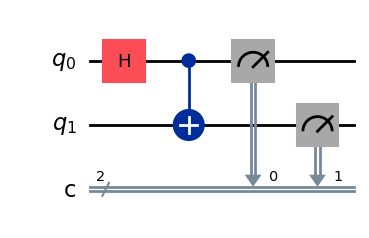

In [9]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0,1)
qc.measure([0, 1], [0, 1])
print("Entanglement Circuit Diagram:")
display(qc.draw(output='mpl'))

Job ID: d6ptnd4u243c739vhtgg
Status: The job is submitted! Check your IBM Quantum dashboard to see your place in the queue.

RESULTS: {'00': 288, '11': 209, '01': 3}


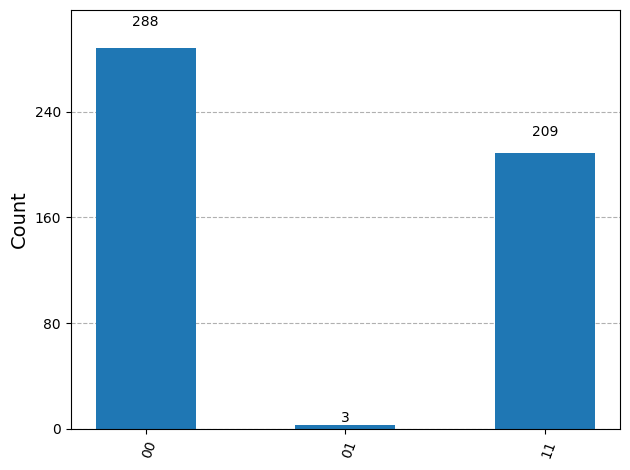

In [17]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# 1. Prepare the circuit for the machine (ISA)
# We use the same 'isa_circuit' you already created
isa_circuit = transpile(qc, backend)

# 2. Open a session and run the Sampler
sampler = Sampler(backend)
job = sampler.run([isa_circuit], shots=500)

print(f"Job ID: {job.job_id()}")
print("Status: The job is submitted! Check your IBM Quantum dashboard to see your place in the queue.")

# 3. Get the results (this will wait for the machine)
result = job.result()

# 4. Extract the counts from the first (and only) circuit we sent
# In V2, results are stored in 'pub_results'
pub_result = result[0]
counts = pub_result.data.c.get_counts()

# 5. Plot the noisy results
from qiskit.visualization import plot_histogram
print("\nRESULTS:", counts)
plot_histogram(counts)